In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
input_path = '/workspaces/My-warehouse/user_personalized_features.csv'
output_dir = '//workspaces/My-warehouse'

In [4]:
#数据加载与预处理函数
def load_and_preprocess(filepath):
    """数据加载与预处理"""
    df = pd.read_csv(filepath)

    # 数据质量检查
    print(f"数据规模: {df.shape[0]} 行 x {df.shape[1]} 列")
    print(f"缺失值: {df.isnull().sum().sum()}")

    # 异常值处理
    age_outliers = df[(df['Age'] < 10) | (df['Age'] > 100)].shape[0]
    print(f"年龄异常值: {age_outliers}")    
    return df

# 执行数据加载
df = load_and_preprocess(input_path)
df.head()

数据规模: 1000 行 x 15 列
缺失值: 0
年龄异常值: 0


,Unnamed: 0,User_ID,Age,Gender,Location,Income,Interests,Last_Login_Days_Ago,Purchase_Frequency,Average_Order_Value,Total_Spending,Product_Category_Preference,Time_Spent_on_Site_Minutes,Pages_Viewed,Newsletter_Subscription
0,0,#1,56,Male,Suburban,38037,Sports,5,7,18,2546,Books,584,38,True
1,1,#2,46,Female,Rural,103986,Technology,15,7,118,320,Electronics,432,40,False
2,2,#3,32,Female,Suburban,101942,Sports,28,1,146,3766,Apparel,306,1,True
3,3,#4,60,Female,Suburban,71612,Fashion,18,3,163,4377,Apparel,527,29,False
4,4,#5,25,Male,Suburban,49725,Travel,2,5,141,4502,Health & Beauty,53,10,True


In [5]:
#特征工程：构建优化指标
def feature_engineering(df):
    """特征工程：构建RFM-I模型所需的所有指标"""

    # 1. 基础RFM指标已在数据中

    # 2. I (Intent - 意向深度)
    def min_max_normalize(series, reverse=False):
        min_val, max_val = series.min(), series.max()
        if max_val == min_val:
            return pd.Series([50] * len(series))
        if reverse:
            return ((max_val - series) / (max_val - min_val)) * 100
        return ((series - min_val) / (max_val - min_val)) * 100
    
    df['Time_Spent_Norm'] = min_max_normalize(df['Time_Spent_on_Site_Minutes'])
    df['Pages_Viewed_Norm'] = min_max_normalize(df['Pages_Viewed'])
    df['I_Score'] = 0.5 * df['Time_Spent_Norm'] + 0.5 * df['Pages_Viewed_Norm']
    df['Friction'] = df['Pages_Viewed'] / (df['Purchase_Frequency'] + 1)

    # 3. L (Loyalty - 活跃连接度)
    def calculate_loyalty(row):
        subscribed = row['Newsletter_Subscription']
        login_days = row['Last_Login_Days_Ago']
        if subscribed and login_days < 7:
            return 3
        elif not subscribed and login_days < 7:
            return 2
        else:
            return 1
    df['L_Score'] = df.apply(calculate_loyalty, axis=1)

    # 4. D (Demographics - 购买力背景)
    income_33 = df['Income'].quantile(0.33)
    income_66 = df['Income'].quantile(0.66)
    def income_level(income):
        if income <= income_33:
            return 'Low'
        elif income <= income_66:
            return 'Medium'
        else:
            return 'High'
    df['Income_Level'] = df['Income'].apply(income_level)

    # 5. 人货匹配度
    df['Interest_Match'] = (df['Interests'] == df['Product_Category_Preference']).astype(int)
    
    print(f"I_Score 范围: [{df['I_Score'].min():.2f}, {df['I_Score'].max():.2f}]")
    print(f"Friction 范围: [{df['Friction'].min():.2f}, {df['Friction'].max():.2f}]")
    print(f"L_Score 分布: {df['L_Score'].value_counts().to_dict()}")
    print(f"Income_Level 分布: {df['Income_Level'].value_counts().to_dict()}")
    print(f"Interest_Match 匹配率: {df['Interest_Match'].mean()*100:.1f}%")
    
    return df

df = feature_engineering(df)
df[['User_ID','I_Score','Friction','L_Score','Income_Level','Interest_Match']].head()

I_Score 范围: [0.00, 98.83]
Friction 范围: [0.10, 49.00]
L_Score 分布: {1: 824, 3: 99, 2: 77}
Income_Level 分布: {'High': 340, 'Low': 330, 'Medium': 330}
Interest_Match 匹配率: 0.0%


,User_ID,I_Score,Friction,L_Score,Income_Level,Interest_Match
0,#1,87.285385,4.750000,3,Low,0
1,#2,76.638400,5.000000,1,High,0
2,#3,25.460637,0.500000,1,High,0
3,#4,73.136516,7.250000,1,Medium,0
4,#5,13.646357,1.666667,3,Low,0


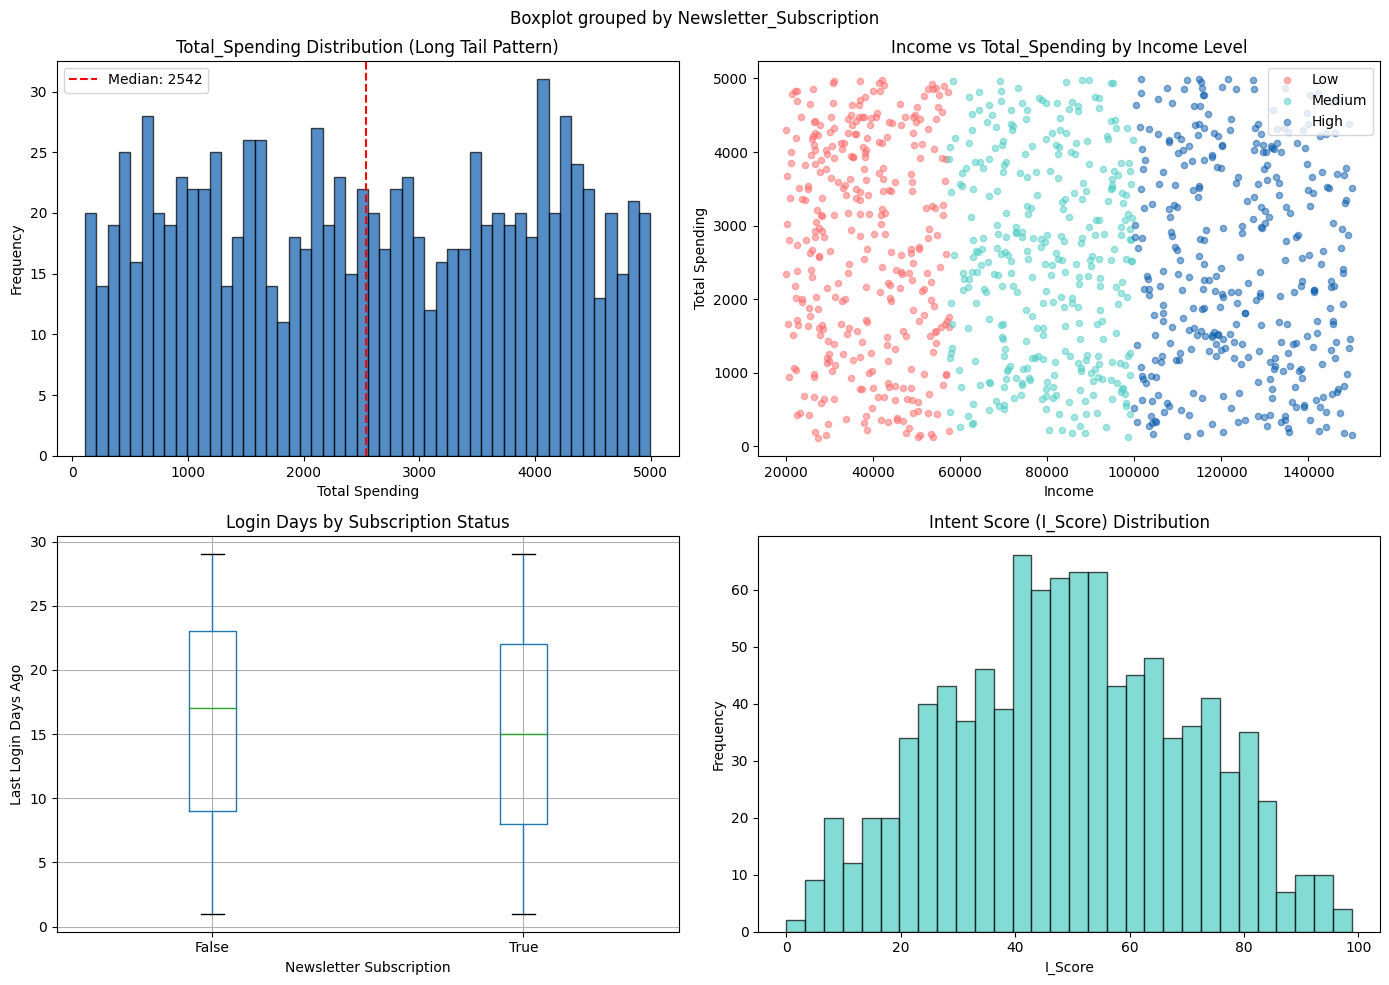

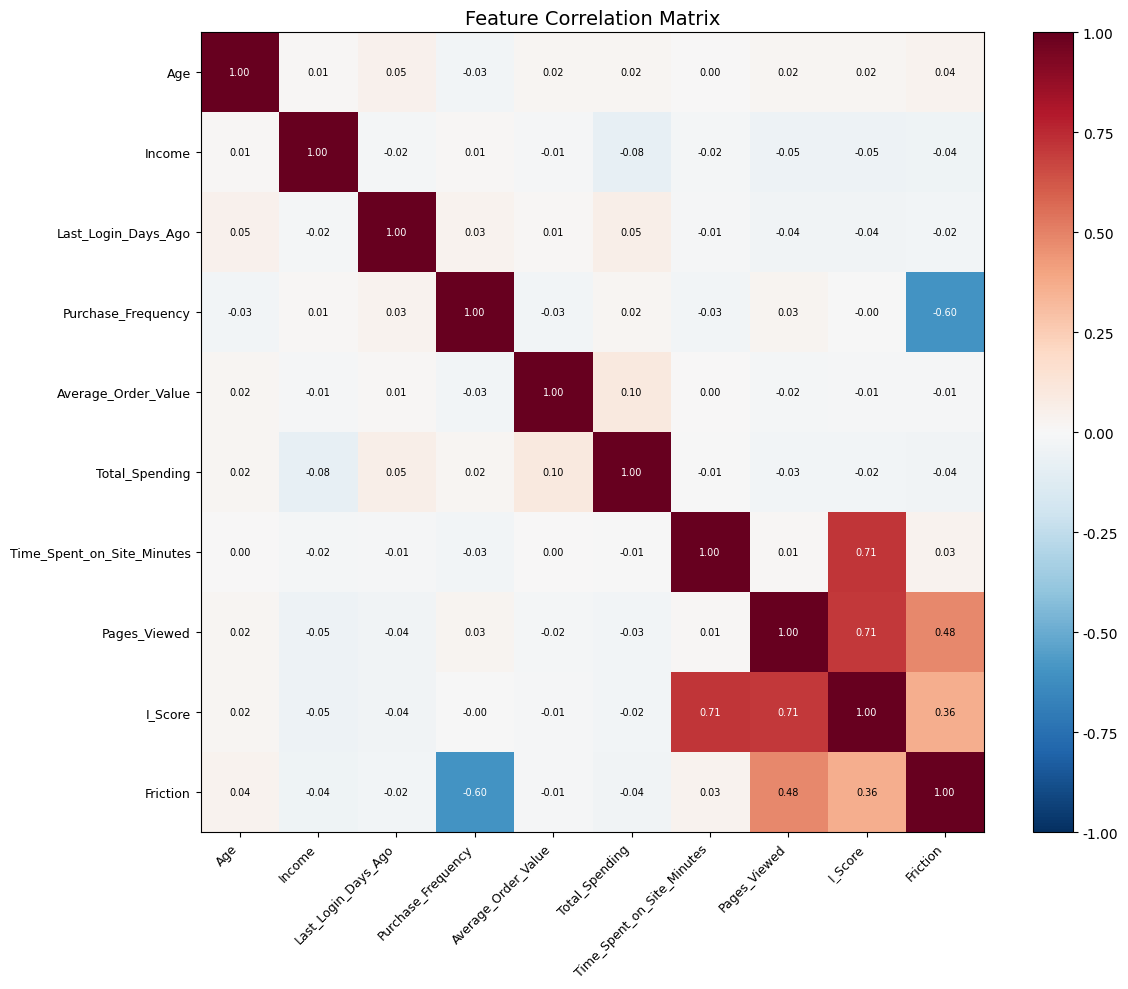


关键相关性分析:
Time_Spent vs Purchase_Frequency 相关系数: -0.028
Pages_Viewed vs Purchase_Frequency 相关系数: 0.026

高摩擦用户(前25%)特征:
  - 平均浏览页数: 34.3
  - 平均购买频率: 1.6
  - 平均消费金额: 2514

高收入低消费群体:
  - 用户数: 184
  - 占高收入群体比例: 54.1%


In [8]:
#EDA探索性数据分析
def perform_eda(df, output_dir):
    """EDA分析：分布、相关性、行为洞察"""

    # 1. 关键分布分析
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Total_Spending 分布
    axes[0, 0].hist(df['Total_Spending'], bins=50, edgecolor='black', alpha=0.7, color='#0B5CAD')
    axes[0, 0].set_title('Total_Spending Distribution (Long Tail Pattern)', fontsize=12)
    axes[0, 0].set_xlabel('Total Spending')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].axvline(df['Total_Spending'].median(), color='red', linestyle='--', 
                       label=f'Median: {df["Total_Spending"].median():.0f}')
    axes[0, 0].legend()

    # Income vs Total_Spending 散点图
    colors = {'Low': '#FF6B6B', 'Medium': '#4ECDC4', 'High': '#0B5CAD'}
    for level in ['Low', 'Medium', 'High']:
        subset = df[df['Income_Level'] == level]
        axes[0, 1].scatter(subset['Income'], subset['Total_Spending'], 
                          alpha=0.5, label=level, c=colors[level], s=20)
    axes[0, 1].set_title('Income vs Total_Spending by Income Level', fontsize=12)
    axes[0, 1].set_xlabel('Income')
    axes[0, 1].set_ylabel('Total Spending')
    axes[0, 1].legend()

    # Last_Login_Days_Ago vs Newsletter_Subscription 箱线图
    df.boxplot(column='Last_Login_Days_Ago', by='Newsletter_Subscription', ax=axes[1, 0])
    axes[1, 0].set_title('Login Days by Subscription Status', fontsize=12)
    axes[1, 0].set_xlabel('Newsletter Subscription')
    axes[1, 0].set_ylabel('Last Login Days Ago') 

    # I_Score 分布
    axes[1, 1].hist(df['I_Score'], bins=30, edgecolor='black', alpha=0.7, color='#4ECDC4')
    axes[1, 1].set_title('Intent Score (I_Score) Distribution', fontsize=12)
    axes[1, 1].set_xlabel('I_Score')
    axes[1, 1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.savefig(f'{output_dir}/eda_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

    # 2. 相关性分析
    numeric_cols = ['Age', 'Income', 'Last_Login_Days_Ago', 'Purchase_Frequency', 
                    'Average_Order_Value', 'Total_Spending', 'Time_Spent_on_Site_Minutes', 
                    'Pages_Viewed', 'I_Score', 'Friction']
    
    corr_matrix = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
    ax.set_xticks(range(len(numeric_cols)))
    ax.set_yticks(range(len(numeric_cols)))
    ax.set_xticklabels(numeric_cols, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(numeric_cols, fontsize=9)

    for i in range(len(numeric_cols)):
        for j in range(len(numeric_cols)):
            text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                          ha='center', va='center', fontsize=7,
                          color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black')

    ax.set_title('Feature Correlation Matrix', fontsize=14)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/correlation_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # 3. 关键行为洞察
    time_purchase_corr = df['Time_Spent_on_Site_Minutes'].corr(df['Purchase_Frequency'])
    pages_purchase_corr = df['Pages_Viewed'].corr(df['Purchase_Frequency'])
    
    print(f"\n关键相关性分析:")
    print(f"Time_Spent vs Purchase_Frequency 相关系数: {time_purchase_corr:.3f}")
    print(f"Pages_Viewed vs Purchase_Frequency 相关系数: {pages_purchase_corr:.3f}")

    # 高摩擦用户分析
    high_friction = df[df['Friction'] > df['Friction'].quantile(0.75)]
    print(f"\n高摩擦用户(前25%)特征:")
    print(f"  - 平均浏览页数: {high_friction['Pages_Viewed'].mean():.1f}")
    print(f"  - 平均购买频率: {high_friction['Purchase_Frequency'].mean():.1f}")
    print(f"  - 平均消费金额: {high_friction['Total_Spending'].mean():.0f}")

    # 高收入低消费群体
    high_income_low_spend = df[(df['Income_Level'] == 'High') & 
                               (df['Total_Spending'] < df['Total_Spending'].median())]
    print(f"\n高收入低消费群体:")
    print(f"  - 用户数: {len(high_income_low_spend)}")
    print(f"  - 占高收入群体比例: {len(high_income_low_spend)/len(df[df['Income_Level']=='High'])*100:.1f}%")
    
    return {
        'time_purchase_corr': time_purchase_corr,
        'pages_purchase_corr': pages_purchase_corr,
        'high_friction_count': len(high_friction),
        'high_income_low_spend_count': len(high_income_low_spend)
    }

eda_results = perform_eda(df, output_dir)